# Notebook 4 – Activation Functions

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
z = np.linspace(-6, 6, 200)

## Why Do We Need Activation Functions At All?

**Explain:** Without an activation function, a neuron is just `z = w1x1 + w2x2 + ... + b` — a **linear** equation. Stacking many linear layers together, with no activation, mathematically collapses into just **one** linear equation, no matter how many layers you add. Activation functions insert **non-linearity**, which is what lets a deep network learn curved, complex patterns (like the XOR problem from Notebook 3).

**Analogy:** Stacking transparent glass sheets doesn't change what light does — it just passes straight through, no matter how many sheets you add. Activation functions are like inserting a **colored, bending lens** between each sheet — now each layer actually changes something, and the combination can do things a single sheet never could.

**Implement:** confirm mathematically that stacking linear layers without activation is the same as one linear layer.

In [2]:
x = 2.0
w1, w2 = 3.0, 0.5          
stacked = (x * w1) * w2  
single = x * (w1 * w2)    
print("Stacked (2 linear layers):", stacked, "| Single equivalent layer:", single)

Stacked (2 linear layers): 3.0 | Single equivalent layer: 3.0


**Interpret:** Both give the exact same result — two linear layers collapsed into one. Without activation functions in between, adding more layers gives the network **no extra power at all**. This is precisely why every hidden layer needs a non-linear activation function.


## 1. Sigmoid

**Explain:** Sigmoid squashes any real number into the range **(0, 1)**, making it useful for representing probabilities.

**Formula:** `sigmoid(z) = 1 / (1 + e^(-z))`

**Range:** (0, 1)

**Analogy:** A dimmer switch that smoothly turns from fully off to fully on, but never quite reaches either extreme.

**Implement:**

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
print("sigmoid(-6, 0, 6) =", sigmoid(np.array([-6, 0, 6])).round(4))

sigmoid(-6, 0, 6) = [0.0025 0.5    0.9975]


**Interpret:** Very negative inputs get squashed near 0, very positive inputs near 1, and 0 maps to exactly 0.5 — the smooth S-shape that gives sigmoid its name.

**Graph:**

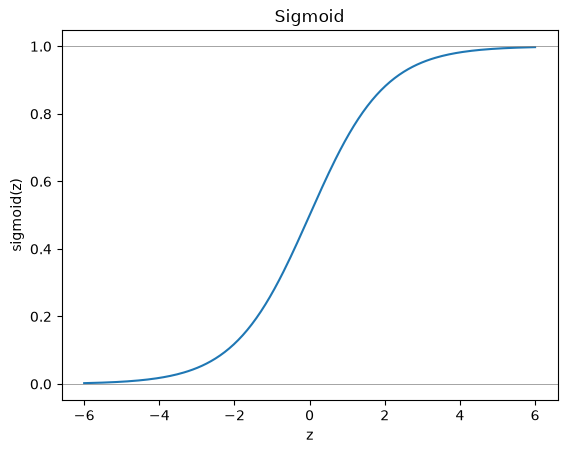

In [4]:
plt.plot(z, sigmoid(z))
plt.title('Sigmoid'); plt.xlabel('z'); plt.ylabel('sigmoid(z)')
plt.axhline(0, color='gray', lw=0.5); plt.axhline(1, color='gray', lw=0.5)
plt.show()

**Advantages:** smooth, outputs interpretable as probabilities — good for the **output layer** of binary classification.

**Limitations:** outputs aren't centered at zero (always positive), and it's expensive to compute (`exp`) compared to simpler alternatives.

**Vanishing gradient:** for very large or very small `z`, the sigmoid curve is almost **flat** — its slope (gradient) is nearly zero there. Implement:

In [5]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)
print("Gradient at z=0:", round(sigmoid_derivative(0), 4))
print("Gradient at z=6:", round(sigmoid_derivative(6), 4))

Gradient at z=0: 0.25
Gradient at z=6: 0.0025


**Interpret:** At `z=0` the gradient is a healthy 0.25, but at `z=6` it's nearly **0.0025** — almost zero. During backpropagation, this tiny gradient gets multiplied through many layers, shrinking further each time, until early layers barely learn at all. This is the **vanishing gradient problem**, and it's the main reason sigmoid is rarely used in hidden layers of deep networks today.

## 2. Tanh

**Explain:** Tanh (hyperbolic tangent) is similar to sigmoid but squashes values into **(-1, 1)** instead, and is centered at zero.

**Formula:** `tanh(z) = (e^z - e^(-z)) / (e^z + e^(-z))`

**Range:** (-1, 1)

**Analogy:** Like sigmoid's dimmer switch, but one that can also go into "negative brightness" — swinging both ways around a true zero point.

**Implement:**

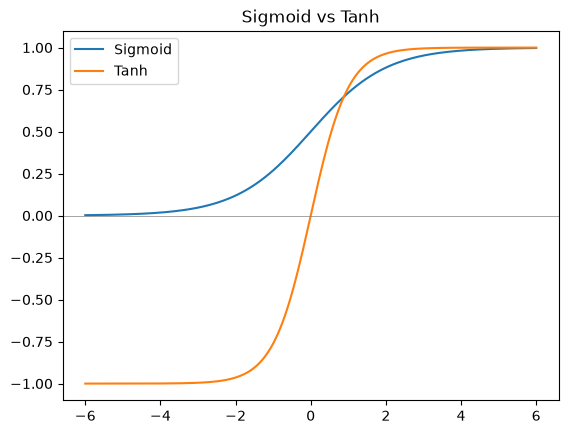

In [6]:
def tanh(z):
    return np.tanh(z)
plt.plot(z, sigmoid(z), label='Sigmoid')
plt.plot(z, tanh(z), label='Tanh')
plt.axhline(0, color='gray', lw=0.5); plt.legend(); plt.title('Sigmoid vs Tanh')
plt.show()

**Interpret:** Tanh has the same S-shape as sigmoid, but stretched to be centered at 0 instead of 0.5.

**Advantages:** zero-centered outputs often help training converge faster than sigmoid, since positive and negative signals can both be represented naturally.

**Limitations:** still suffers from **vanishing gradients** at extreme values (same flattening problem as sigmoid, just mirrored around zero) — so it's also rarely used in very deep hidden layers.


## 3. ReLU

**Explain:** ReLU (Rectified Linear Unit) outputs the input directly if positive, and **0** if negative — the simplest possible non-linearity.

**Formula:** `ReLU(z) = max(0, z)`

**Implement:**

In [7]:
def relu(z):
    return np.maximum(0, z)
print("relu(-3, 0, 3) =", relu(np.array([-3, 0, 3])))

relu(-3, 0, 3) = [0 0 3]


**Interpret:** Negative values are clipped to exactly 0; positive values pass through completely unchanged — no squashing at all for the positive side.

**Graph:**

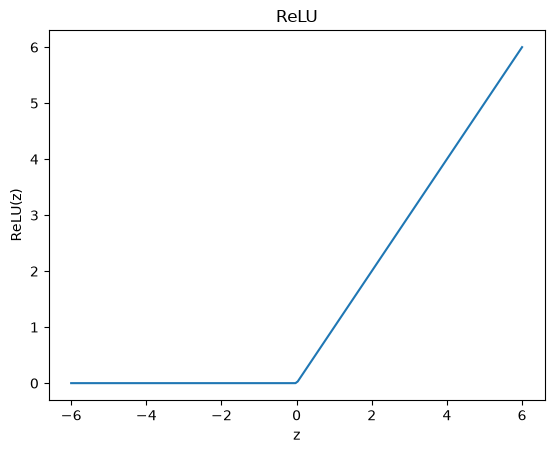

In [8]:
plt.plot(z, relu(z))
plt.title('ReLU'); plt.xlabel('z'); plt.ylabel('ReLU(z)')
plt.show()

**Why ReLU became popular:**
1. **No vanishing gradient for positive inputs** — the gradient is exactly 1 for any positive `z`, no matter how large, so signals don't shrink through many layers.
2. **Very cheap to compute** — just a comparison with zero, no exponentials.
3. **Encourages sparsity** — many neurons output exactly 0, which can make representations more efficient.

**Dying ReLU problem:** if a neuron's weights update such that its output is **always negative**, it always outputs 0 and its gradient is also always 0 — it stops learning entirely and is effectively "dead" forever.

**Implement:** show that ReLU's gradient is exactly 0 for any negative input.

In [9]:
relu_gradient = lambda zz: (zz > 0).astype(float)
print("ReLU gradient at z=-5, 0, 5:", relu_gradient(np.array([-5, 0, 5])))

ReLU gradient at z=-5, 0, 5: [0. 0. 1.]


**Interpret:** For `z=-5` the gradient is exactly `0.0` — if a neuron gets stuck always producing negative `z`, no gradient ever flows back through it, so its weights never update again. This permanently "dead" neuron is the dying ReLU problem.


## 4. Leaky ReLU

**Purpose:** Fix the dying ReLU problem by allowing a **small, non-zero gradient** even for negative inputs, instead of a hard 0.

**Formula:** `LeakyReLU(z) = z if z > 0 else (alpha * z)`, where `alpha` is small (e.g. 0.01).

**Difference from ReLU:** Standard ReLU completely zeroes out negative values (and their gradients). Leaky ReLU lets a small fraction of the negative signal "leak" through, so the gradient is never exactly zero — a "dead" neuron can still recover.

**Implement:**

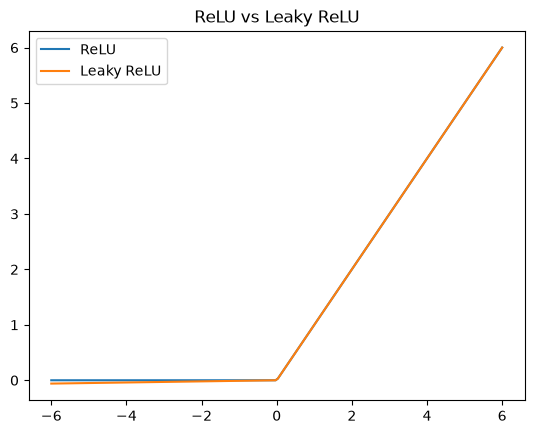

In [10]:
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)
plt.plot(z, relu(z), label='ReLU')
plt.plot(z, leaky_relu(z), label='Leaky ReLU')
plt.legend(); plt.title('ReLU vs Leaky ReLU'); plt.show()

**Interpret:** For positive `z`, both functions look identical. For negative `z`, standard ReLU is flat at 0, while Leaky ReLU has a slight downward slope — small enough to barely change positive behavior, but enough to keep a tiny gradient alive for negative inputs, preventing neurons from dying permanently.


## 5. Softmax

**Purpose:** Softmax converts a vector of raw scores (one per class) into a **probability distribution** — all outputs are positive and **sum to exactly 1**. It's used in the **output layer for multiclass classification** (e.g. predicting which of several countries an order is from).

**Probability interpretation:** each output can be read directly as "the model's estimated probability of this class."

**Formula:** `softmax(z_i) = e^(z_i) / sum(e^(z_j) for all j)`

**Implement:**

In [11]:
def softmax(scores):
    exp_scores = np.exp(scores - np.max(scores))   
    return exp_scores / exp_scores.sum()
class_scores = np.array([2.0, 1.0, 0.1])   
probs = softmax(class_scores)
print("Probabilities:", probs.round(3), "| Sum:", round(probs.sum(), 3))

Probabilities: [0.659 0.242 0.099] | Sum: 1.0


**Interpret:** The raw scores `[2.0, 1.0, 0.1]` became probabilities `[0.659, 0.242, 0.099]` that **sum to exactly 1** — the highest raw score gets the highest probability, and we can now say "the model is 66% confident in class 0." This is exactly how multiclass classification output layers work (sigmoid, by contrast, is only for binary classification — softmax generalizes it to many classes).


## Comparing the Activation Functions

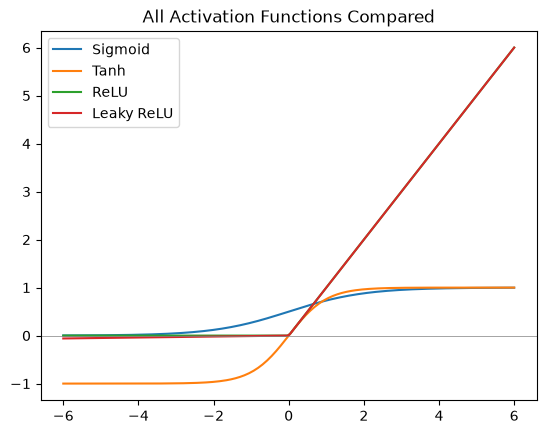

In [12]:
fig, ax = plt.subplots()
ax.plot(z, sigmoid(z), label='Sigmoid')
ax.plot(z, tanh(z), label='Tanh')
ax.plot(z, relu(z), label='ReLU')
ax.plot(z, leaky_relu(z), label='Leaky ReLU')
ax.axhline(0, color='gray', lw=0.5); ax.legend(); ax.set_title('All Activation Functions Compared')
plt.show()